# University of London - ML Code - Computer Science Final Project

**BSc Computer Science**

**Subject: CM3070 Computer Science Final Project**

**Student: In Final Project report**

**Student Number: In Final Project report**

## Preparing the data

### Transforming the csv data to a numpy array

In [1]:
import numpy as np

usdYen_raw_data = np.genfromtxt("./data/currency-data/USD-JPY.csv", skip_header=1, delimiter=";", usecols=1)

print("Length: ",len(usdYen_raw_data))
print("Data type: ",usdYen_raw_data.dtype)
print("Raw Data: ",usdYen_raw_data)

Length:  550
Data type:  float64
Raw Data:  [155.21  155.81  155.34  156.15  156.39  154.54  153.4   154.    152.85
 150.62  151.15  147.44  149.49  147.94  147.66  147.38  147.02  146.93
 147.18  147.72  147.36  147.66  148.81  147.4   144.55  144.65  146.07
 144.09  144.85  144.021 142.55  145.581 145.323 144.918 143.623 142.15
 143.49  146.935 149.83  149.275 148.61  148.018 150.545 149.262 152.254
 151.377 155.182 155.92  156.266 157.657 157.273 157.772 156.407 153.683
 149.989 149.743 154.73  154.309 152.608 152.946 152.244 149.485 149.09
 148.679 142.15  143.808 140.764 142.251 146.176 144.367 147.579 146.634
 146.519 153.718 157.44  157.848 160.719 160.835 159.767 157.323 156.752
 157.29  156.943 155.619 155.703 152.949 158.296 154.562 153.24  151.609
 151.303 151.429 149.033 147.03  150.064 150.473 150.181 149.256 148.308
 148.149 148.128 144.904 144.603 140.998 142.401 142.141 144.893 146.772
 149.403 149.562 151.472 149.333 149.599 149.831 149.515 149.274 149.33
 148.36  147.

As the currency data is from newer to older, the order should be inverted.

In [2]:
usdYen_raw_data = np.flip(usdYen_raw_data, axis=0)
print(usdYen_raw_data)

[123.408 122.681 123.861 122.851 122.83  124.05  123.79  123.85  124.197
 124.276 122.002 121.703 119.017 120.567 119.92  120.584 119.898 120.246
 119.442 121.452 120.608 123.136 122.579 122.755 122.741 123.056 120.954
 121.146 120.289 120.203 117.234 116.98  118.71  121.14  116.808 113.236
 112.603 113.975 113.735 113.96  111.543 113.049 111.64  108.079 108.762
 111.793 106.282 107.094 108.633 110.097 110.214 106.532 106.91  104.11
 102.19  102.518 100.5   104.651 106.149 102.047 101.821 101.25  100.21
 101.81  103.975 102.67  102.27  101.05  101.32  102.893 104.146 103.8
 104.694 103.089 106.635 110.874 113.229 113.503 115.274 117.84  117.32
 116.95  117.02  114.467 114.6   115.08  112.584 113.205 112.836 112.134
 114.005 114.77  112.69  111.329 111.383 111.044 108.48  109.08  111.495
 112.7   113.28  111.16  111.31  110.357 110.327 110.67  111.26  112.36
 113.869 112.48  111.153 110.654 110.64  109.05  109.14  109.36  110.247
 107.83  110.731 111.958 112.428 112.545 111.791 113.479 

### Computing the numer of samples for each data split

In [3]:
train_samples_number = len(usdYen_raw_data)
print("Number of train samples: ", train_samples_number)

Number of train samples:  550


### Normalizing data

In [4]:
'''
mean = usdYen_raw_data[:train_samples_number].mean(axis=0)
usdYen_raw_data -= mean
std = usdYen_raw_data[:train_samples_number].std(axis=0)
usdYen_raw_data /= std

print(usdYen_raw_data)
'''

'\nmean = usdYen_raw_data[:train_samples_number].mean(axis=0)\nusdYen_raw_data -= mean\nstd = usdYen_raw_data[:train_samples_number].std(axis=0)\nusdYen_raw_data /= std\n\nprint(usdYen_raw_data)\n'

### Creating timeseries data

In [5]:
from tensorflow import keras

# Parameters
sampling_rate = 1
sequence_length = 4 # Observations will go back 4 weeks
delay = sampling_rate * (sequence_length + 4 - 1) # target is 4 weeks after the end of the sequence
batch_size = train_samples_number # small batch size to start

# train dataset
train_dataset = keras.utils.timeseries_dataset_from_array(
    usdYen_raw_data[:-delay],
    targets=usdYen_raw_data[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    batch_size=batch_size,
)

Checking that it works correctly

In [6]:
for inputs, targets in train_dataset:
    for i in range(inputs.shape[0]):
        print([float(x) for x in inputs[i]], float(targets[i]))

[123.408, 122.681, 123.861, 122.851] 123.85
[122.681, 123.861, 122.851, 122.83] 124.197
[123.861, 122.851, 122.83, 124.05] 124.276
[122.851, 122.83, 124.05, 123.79] 122.002
[122.83, 124.05, 123.79, 123.85] 121.703
[124.05, 123.79, 123.85, 124.197] 119.017
[123.79, 123.85, 124.197, 124.276] 120.567
[123.85, 124.197, 124.276, 122.002] 119.92
[124.197, 124.276, 122.002, 121.703] 120.584
[124.276, 122.002, 121.703, 119.017] 119.898
[122.002, 121.703, 119.017, 120.567] 120.246
[121.703, 119.017, 120.567, 119.92] 119.442
[119.017, 120.567, 119.92, 120.584] 121.452
[120.567, 119.92, 120.584, 119.898] 120.608
[119.92, 120.584, 119.898, 120.246] 123.136
[120.584, 119.898, 120.246, 119.442] 122.579
[119.898, 120.246, 119.442, 121.452] 122.755
[120.246, 119.442, 121.452, 120.608] 122.741
[119.442, 121.452, 120.608, 123.136] 123.056
[121.452, 120.608, 123.136, 122.579] 120.954
[120.608, 123.136, 122.579, 122.755] 121.146
[123.136, 122.579, 122.755, 122.741] 120.289
[122.579, 122.755, 122.741, 123.

2025-12-17 17:18:44.189629: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Inspecting the output

In [7]:
import tensorflow as tf

data_inputs = []
data_outputs = []

for samples, targets in train_dataset:
    print("Samples: ", samples)
    print("Sample shape: ", samples.shape)
    print("Targets: ", targets)
    print("Targets shape: ", targets.shape)
    data_inputs = tf.make_ndarray(tf.make_tensor_proto(samples))
    data_outputs = tf.make_ndarray(tf.make_tensor_proto(targets))

Samples:  tf.Tensor(
[[123.408 122.681 123.861 122.851]
 [122.681 123.861 122.851 122.83 ]
 [123.861 122.851 122.83  124.05 ]
 ...
 [149.49  147.44  151.15  150.62 ]
 [147.44  151.15  150.62  152.85 ]
 [151.15  150.62  152.85  154.   ]], shape=(540, 4), dtype=float64)
Sample shape:  (540, 4)
Targets:  tf.Tensor(
[123.85  124.197 124.276 122.002 121.703 119.017 120.567 119.92  120.584
 119.898 120.246 119.442 121.452 120.608 123.136 122.579 122.755 122.741
 123.056 120.954 121.146 120.289 120.203 117.234 116.98  118.71  121.14
 116.808 113.236 112.603 113.975 113.735 113.96  111.543 113.049 111.64
 108.079 108.762 111.793 106.282 107.094 108.633 110.097 110.214 106.532
 106.91  104.11  102.19  102.518 100.5   104.651 106.149 102.047 101.821
 101.25  100.21  101.81  103.975 102.67  102.27  101.05  101.32  102.893
 104.146 103.8   104.694 103.089 106.635 110.874 113.229 113.503 115.274
 117.84  117.32  116.95  117.02  114.467 114.6   115.08  112.584 113.205
 112.836 112.134 114.005 114.77

2025-12-17 17:18:44.222666: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [8]:
print("----")
print("Input Data: ", len(data_inputs))
print("----")
print("Output Data: ", len(data_outputs))
print("----")

----
Input Data:  540
----
Output Data:  540
----


## Simple LSTM Model

In [9]:
from keras import models
from keras import layers

def build_lstm_model():
    model = models.Sequential()
    model.add(layers.LSTM(16, input_shape=(sequence_length, 1)))
    model.add(layers.Dense(1))
    model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
    return model

prototype_model = build_lstm_model()

/Users/studentcode/Documents/UOL/Semester 6/Computer Science Final Project/ML - CM3070 - In Final Project report - University of London/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### - PyGad

Instance of the pygad.kerasga.KerasGA class

In [10]:
import pygad.kerasga

keras_ga = pygad.kerasga.KerasGA(model=prototype_model, num_solutions=10)

Fitness function

In [11]:
def fitness_function(ga_instance, solution, solution_index):
    global data_inputs, data_outputs, keras_ga, prototype_model
    predictions = pygad.kerasga.predict(model=prototype_model, solution=solution, data=data_inputs)
    mae = keras.losses.MeanAbsoluteError()
    absolute_error = mae(data_outputs, predictions).numpy() + + 0.00000001
    solution_fitness = 20 / absolute_error
    return solution_fitness

Track GA

In [12]:
def on_generation(ga_instance):
    print(f"Generation = {ga_instance.generations_completed}")
    print(f"Fitness    = {ga_instance.best_solution()[1]}")

Create instance of the pygad.GA class

In [13]:
num_generations = 50 
num_parents_mating = 10
initial_population = keras_ga.population_weights

ga_instance = pygad.GA(num_generations=num_generations,
                       num_parents_mating=num_parents_mating,
                       initial_population=initial_population,
                       fitness_func=fitness_function,
                       on_generation=on_generation)

In [14]:
ga_instance.run()

Generation = 1
Fitness    = 0.1668531447649002
Generation = 2
Fitness    = 0.1668531447649002
Generation = 3
Fitness    = 0.16929806768894196
Generation = 4
Fitness    = 0.16929806768894196
Generation = 5
Fitness    = 0.16929806768894196
Generation = 6
Fitness    = 0.16929806768894196
Generation = 7
Fitness    = 0.16929806768894196
Generation = 8
Fitness    = 0.16929806768894196
Generation = 9
Fitness    = 0.16929806768894196
Generation = 10
Fitness    = 0.16929806768894196
Generation = 11
Fitness    = 0.16929806768894196
Generation = 12
Fitness    = 0.16929806768894196
Generation = 13
Fitness    = 0.16929806768894196
Generation = 14
Fitness    = 0.16929806768894196
Generation = 15
Fitness    = 0.16929806768894196
Generation = 16
Fitness    = 0.16929806768894196
Generation = 17
Fitness    = 0.16929806768894196
Generation = 18
Fitness    = 0.16929806768894196
Generation = 19
Fitness    = 0.16929806768894196
Generation = 20
Fitness    = 0.16929806768894196
Generation = 21
Fitness    = 0.

/Users/studentcode/Documents/UOL/Semester 6/Computer Science Final Project/ML - CM3070 - In Final Project report - University of London/.venv/lib/python3.13/site-packages/pygad/visualize/plot.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  matplt.legend()


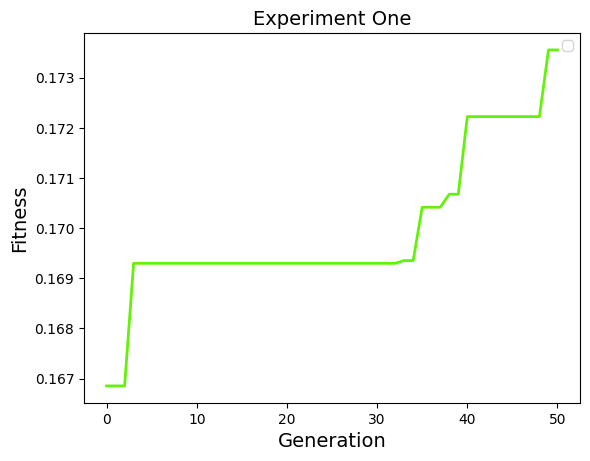

Figure(640x480)


In [17]:
print(ga_instance.plot_fitness(title="Experiment One", linewidth=2))